<p> 
    目前的家禽資料量有限，LSTM / xLSTM 模型可能出現過擬合。<br>
    但這裡的研究目的是探索其可行性，並建立一個方法論上的 baseline。<br>
    未來只要有更多批次資料，就能更嚴謹地驗證這個模型的泛化能力。
</p>

<ol style="color: blue;">
  <li>讀取原始 Kaggle ChickWeight</li>
  <li>移除 <code>Diet</code> 欄位</li>
  <li><code>Time</code> 改名為 <code>Age</code></li>
  <li>篩除沒有完整紀錄到 <code>Age = 21</code> 的雞隻</li>
  <li>依據福壽 Target-like growth 規則篩選曲線</li>
  <li>將 <code>Age</code> 補成每日 <code>0~21</code></li>
  <li>做 daily statistics 或後續模型資料集</li>
</ol>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
import seaborn as sns
import os
import pickle

In [2]:
from sklearn.linear_model import LinearRegression  # [Additional] 求得回歸方程式

<h3> Definition </h3>

In [3]:
def plot_chick_growth(data, show_legend=False, figsize=(20, 10)):
    """
    繪製每隻雞隻的生長曲線（體重 vs 日齡）

    參數:
        data : DataFrame
            包含 'Chick', 'Age', 'weight' 三個欄位
        show_legend : bool, optional
            是否顯示圖例（預設 False）
        figsize : tuple, optional
            圖片大小，預設 (20, 10)
    """

    # 創建圖形
    fig, ax = plt.subplots(figsize=figsize)

    # 繪製每隻雞隻的體重趨勢
    for chick_id in data['Chick'].unique():
        chick_data = data[data['Chick'] == chick_id]
        ax.plot(chick_data['Age'], chick_data['weight'], marker='o', linestyle='-', label=f'Chick {chick_id}')

    # 設置標題和軸標籤
    ax.set_title('Weight Trends for Each Chick')
    ax.set_xlabel('Age (days)')
    ax.set_ylabel('Weight')

    # 是否顯示圖例
    if show_legend:
        ax.legend()

    plt.show()

In [5]:
def daily_features(group):
    
    """
    對同一個 Age（日齡）下所有雞隻的 weight 進行聚合，
    建立每日統計特徵，用於後續 SourceData Pre-Train。

    輸入:
        group: 同一天 Age 下，多隻雞的 weight 序列

    輸出:
        min     : 最小體重
        max     : 最大體重
        range   : 體重範圍 max - min
        p25     : 第 25 百分位數
        p75     : 第 75 百分位數
        IQR     : 四分位距 p75 - p25
        median  : 中位數
        std     : 標準差
        mean    : 平均體重，後續可作為 label / target
    """
    
    group = pd.Series(group).dropna()

    p25 = np.percentile(group, 25)
    p75 = np.percentile(group, 75)

    return pd.Series({
        "min": group.min(),
        "max": group.max(),
        "range": group.max() - group.min(),
        "p25": p25,
        "p75": p75,
        "IQR": p75 - p25,
        "median": group.median(),
        "std": group.std(),
        "mean": group.mean()
    })

In [6]:
# 讀取csv檔案
data = pd.read_csv('ChickWeight.csv', index_col=0) # 讀取 ChickWeight.csv 檔案
data

,weight,Time,Chick,Diet
1,42,0,1,1
2,51,2,1,1
3,59,4,1,1
4,64,6,1,1
5,76,8,1,1
...,...,...,...,...
574,175,14,50,4
575,205,16,50,4
576,234,18,50,4
577,264,20,50,4


In [7]:
# 忽略Diet餵養雞隻的飼料種類。
data.drop('Diet', axis=1, inplace=True)
# 調整欄位排序
data = data[['Chick', 'Time', 'weight']]
# 更改欄位名稱，Time→Age
data = data.rename(columns={'Time': 'Age'})
data

,Chick,Age,weight
1,1,0,42
2,1,2,51
3,1,4,59
4,1,6,64
5,1,8,76
...,...,...,...
574,50,14,175
575,50,16,205
576,50,18,234
577,50,20,264


In [8]:
# 獲取關於資料表的詳細訊息，有多少Null值。
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578 entries, 1 to 578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Chick   578 non-null    int64
 1   Age     578 non-null    int64
 2   weight  578 non-null    int64
dtypes: int64(3)
memory usage: 18.1 KB


<p> 顯示 每筆都有值（沒有缺失值） </p>

In [9]:
data.isnull().sum()

Chick     0
Age       0
weight    0
dtype: int64

<h3> 觀察資料異常值 </h3>

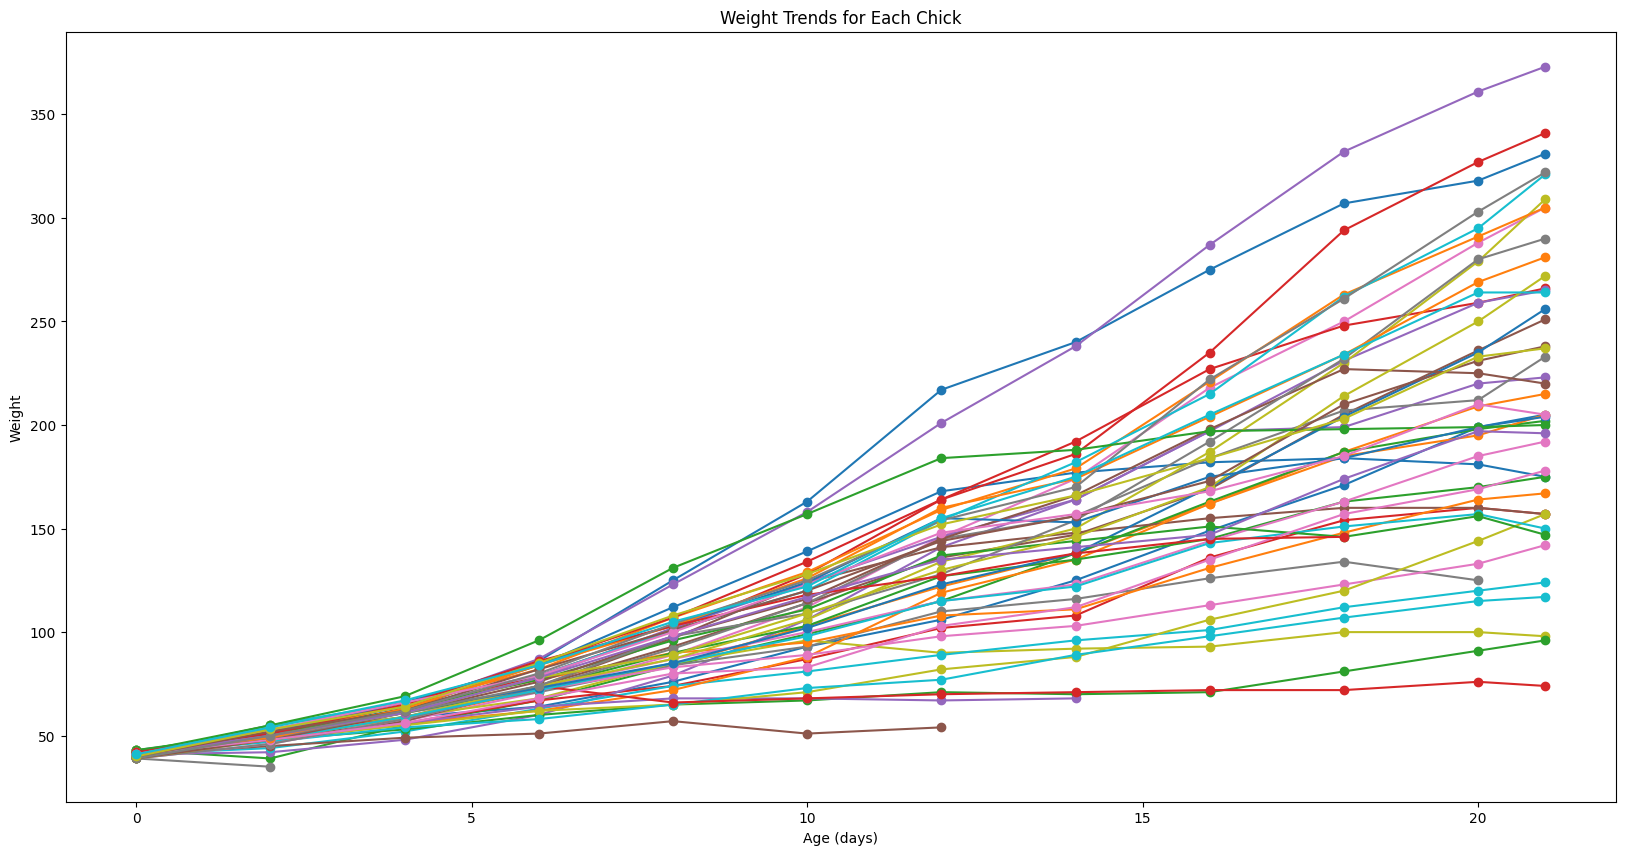

In [10]:
# 所有雞隻的生長曲線
plot_chick_growth(data) # 繪製所有雞隻生長曲線

<p style='color:blue'> ↑ 尚未刪除任何雞隻資料的曲線 </p>

<h4> 篩除掉沒有完整 21 天日齡的雞隻 </h4>
<p> 有些雞隻的曲線在某些天數中斷，代表資料 不完整（少於 21 天的紀錄）。 </p>

In [11]:
complete_chicks = (
    data.groupby("Chick")["Age"]
    .max()                     # 每隻雞的最大日齡
    .loc[lambda x: x >= 21]    # 篩選出有觀察到至少 21 日齡的
    .index
)

# 過濾掉不完整的雞
data_complete = data[data["Chick"].isin(complete_chicks)]

print(f"原本有 {data['Chick'].nunique()} 隻雞")
print(f"完整21天的雞有 {data_complete['Chick'].nunique()} 隻")

原本有 50 隻雞
完整21天的雞有 45 隻


In [12]:
# 找出最大日齡 < 21 的雞（不完整）
incomplete_chicks = (
    data.groupby("Chick")["Age"]
    .max()
    .loc[lambda x: x < 21]   # 最大日齡小於 21
    .index
)

print(f"沒有存活到 21 天的雞共有 {len(incomplete_chicks)} 隻")
print("它們的編號是：", list(incomplete_chicks))

沒有存活到 21 天的雞共有 5 隻
它們的編號是： [8, 15, 16, 18, 44]


In [13]:
# 移除有缺失值的資料 (雞隻編號第8筆、第15筆、第16筆、第18筆、第44筆有缺少數據)
indexes_to_drop = data[data['Chick'].isin([8, 15, 16, 18, 44])].index
data = data.drop(indexes_to_drop) # inplace=True
data

,Chick,Age,weight
1,1,0,42
2,1,2,51
3,1,4,59
4,1,6,64
5,1,8,76
...,...,...,...
574,50,14,175
575,50,16,205
576,50,18,234
577,50,20,264


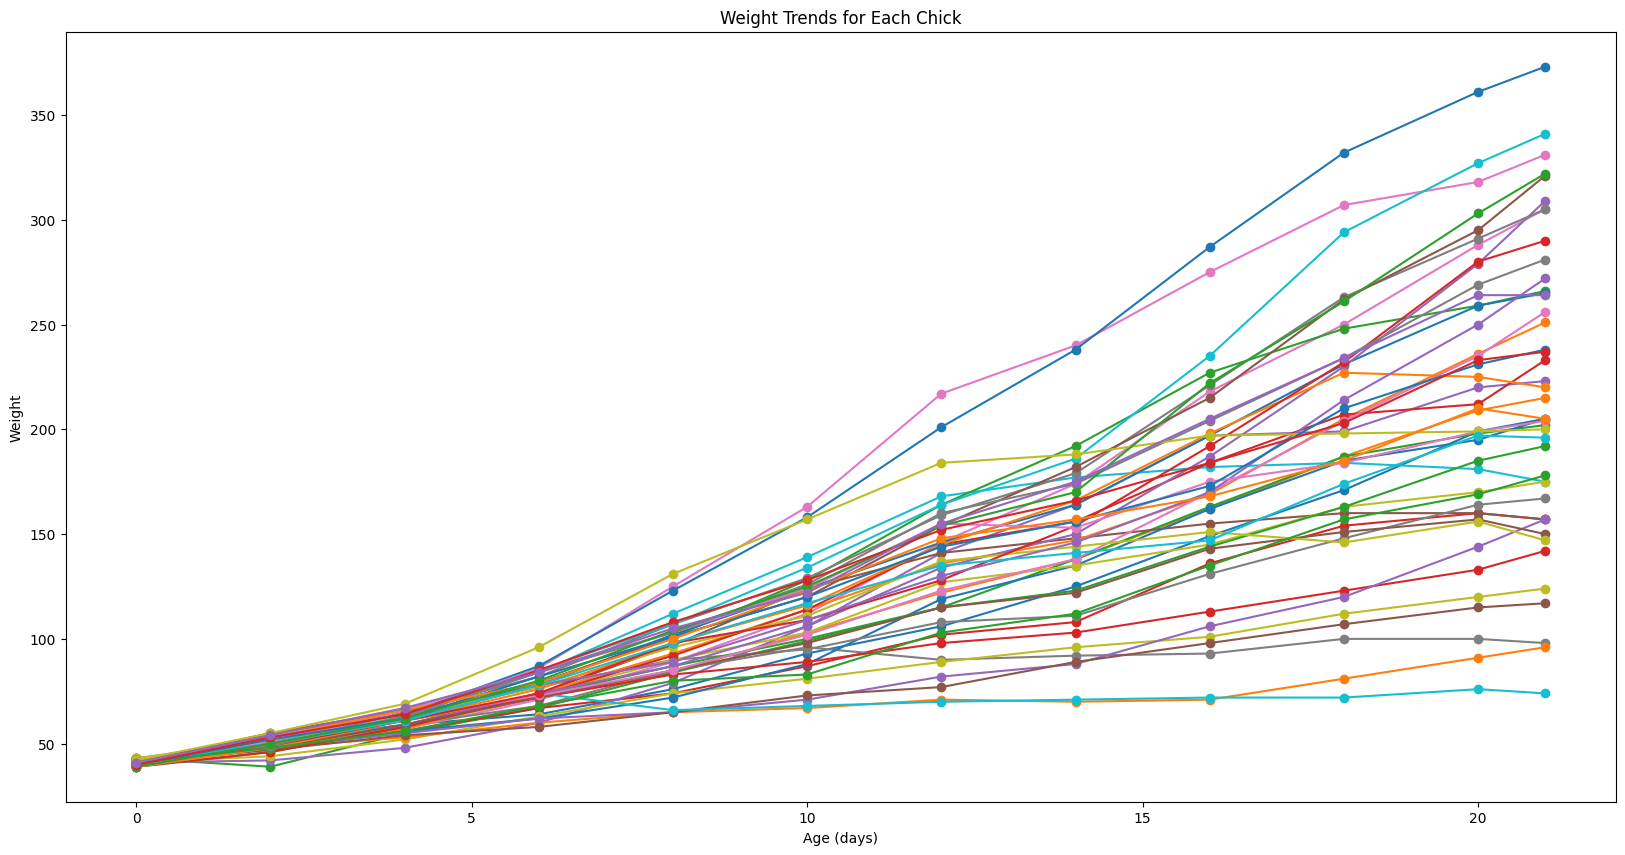

In [14]:
# 只保留有完整21天日齡的雞隻曲線
plot_chick_growth(data) # 繪製所有雞隻生長曲線

<p style='color:blue'> ↑ 刪除沒有完整21天資料的雞隻。維護本次實驗資料的完整性，確保所有在研資料均包含完整的21天生長週期資訊。 </p>

In [15]:
data.to_csv("Kaggle SourceData.csv", index=True, encoding="utf-8-sig")

<h3> 補插值（linear interpolation) </h3>
建立完整日齡範圍 & 補值，變成每天都有雞隻的體重資料。

In [18]:
# === Step. Kaggle SourceData：建立 0~21 日齡每日資料 ===
# 確保排序正確
data = data.sort_values(["Chick", "Age"]).reset_index(drop=True)

# 建立 0–21 天完整日齡範圍
full_range = pd.DataFrame([
    (chick, age)
    for chick in sorted(data["Chick"].unique())
    for age in range(0, 22)
], columns=["Chick", "Age"])

# merge 回原始資料，缺的日齡會變成 NaN
data_full = pd.merge(
    full_range,
    data,
    on=["Chick", "Age"],
    how="left"
)

# 再次排序
data_full = data_full.sort_values(["Chick", "Age"]).reset_index(drop=True)

# 對每隻雞分開做線性插值
data_full["weight"] = (
    data_full
    .groupby("Chick")["weight"]
    .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
)

# 檢查結果
check_count = data_full.groupby("Chick")["Age"].count()

print("雞隻數:", data_full["Chick"].nunique())
print("資料筆數:", data_full.shape[0])
print("每隻雞資料筆數是否皆為 22:", (check_count == 22).all())

print("\n每隻雞資料筆數分布:")
print(check_count.value_counts().sort_index())

print("\n缺失值檢查:")
print(data_full.isna().sum())

# 更新 data
data = data_full.copy()

display(data.head(30))

雞隻數: 45
資料筆數: 990
每隻雞資料筆數是否皆為 22: True

每隻雞資料筆數分布:
Age
22    45
Name: count, dtype: int64

缺失值檢查:
Chick     0
Age       0
weight    0
dtype: int64


,Chick,Age,weight
0,1,0,42.0
1,1,1,46.5
2,1,2,51.0
3,1,3,55.0
4,1,4,59.0
5,1,5,61.5
6,1,6,64.0
7,1,7,70.0
8,1,8,76.0
9,1,9,84.5


In [19]:
# TODO: 建立 Chick × Age 生長曲線表
# === Step 1. 建立 Kaggle SourceData 生長曲線 Pivot Table ===

# 確保排序
data = data.sort_values(["Chick", "Age"]).reset_index(drop=True)

# 建立 pivot table
# index = Age（日齡）
# columns = Chick（雞隻編號）
# values = weight（體重）
kaggle_growth_pivot = data.pivot_table(
    index="Age",
    columns="Chick",
    values="weight",
    aggfunc="mean"
)

# 依 Age 由小到大排序
kaggle_growth_pivot = kaggle_growth_pivot.sort_index()

print("Kaggle Growth Pivot shape:", kaggle_growth_pivot.shape)
display(kaggle_growth_pivot)

Kaggle Growth Pivot shape: (22, 45)


Chick,1,2,3,4,5,6,7,9,10,11,...,40,41,42,43,45,46,47,48,49,50
Age,,,,,,,,,,,,,,,,,,,,,
0,42.0,40.0,43.0,42.0,41.0,41.0,41.0,42.0,41.0,43.0,...,41.0,42.0,42.0,42.0,41.0,40.0,41.0,39.0,40.0,41.0
1,46.5,44.5,41.0,45.5,41.5,45.0,45.0,46.5,42.5,47.0,...,48.0,46.5,45.5,48.5,45.5,46.0,47.0,44.5,46.5,47.5
2,51.0,49.0,39.0,49.0,42.0,49.0,49.0,51.0,44.0,51.0,...,55.0,51.0,49.0,55.0,50.0,52.0,53.0,50.0,53.0,54.0
3,55.0,53.5,47.0,52.5,45.0,54.0,53.0,55.0,48.0,57.0,...,60.5,58.5,56.0,62.0,55.5,57.0,59.5,56.0,58.5,60.5
4,59.0,58.0,55.0,56.0,48.0,59.0,57.0,59.0,52.0,63.0,...,66.0,66.0,63.0,69.0,61.0,62.0,66.0,62.0,64.0,67.0
5,61.5,65.0,61.0,61.5,54.0,66.5,64.0,63.5,57.5,73.5,...,72.5,75.5,73.5,82.5,69.5,72.0,72.5,71.0,74.5,75.5
6,64.0,72.0,67.0,67.0,60.0,74.0,71.0,68.0,63.0,84.0,...,79.0,85.0,84.0,96.0,78.0,82.0,79.0,80.0,85.0,84.0
7,70.0,78.0,75.5,70.5,69.5,85.5,80.0,76.5,68.5,98.0,...,90.0,94.0,93.5,113.5,88.0,91.5,89.5,92.0,96.5,94.5
8,76.0,84.0,84.0,74.0,79.0,97.0,89.0,85.0,74.0,112.0,...,101.0,103.0,103.0,131.0,98.0,101.0,100.0,104.0,108.0,105.0


In [20]:
# TODO: 檢查每隻雞是否遞增
# === Step 2. 檢查每隻雞生長曲線是否遞增 ===
def check_kaggle_growth_curve(group):
    group = group.sort_values("Age")
    
    ages = group["Age"].values
    weights = group["weight"].values.astype(float)
    
    diffs = np.diff(weights)
    
    start_weight = weights[0]
    end_weight = weights[-1]
    total_growth = end_weight - start_weight
    
    decrease_count = int(np.sum(diffs < 0))
    non_decreasing_ratio = float(np.mean(diffs >= 0)) if len(diffs) > 0 else np.nan
    
    max_drop = float(diffs.min()) if len(diffs) > 0 else 0.0
    max_drop_abs = abs(max_drop) if max_drop < 0 else 0.0
    max_drop_ratio = max_drop_abs / total_growth if total_growth > 0 else np.inf
    
    return pd.Series({
        "age_min": ages.min(),
        "age_max": ages.max(),
        "n_records": len(group),
        "start_weight": start_weight,
        "end_weight": end_weight,
        "total_growth": total_growth,
        "is_strictly_increasing": bool(np.all(diffs > 0)),
        "is_non_decreasing": bool(np.all(diffs >= 0)),
        "decrease_count": decrease_count,
        "non_decreasing_ratio": non_decreasing_ratio,
        "max_drop": max_drop,
        "max_drop_abs": max_drop_abs,
        "max_drop_ratio": max_drop_ratio
    })

kaggle_growth_check = (
    data.groupby("Chick")
    .apply(check_kaggle_growth_curve)
    .reset_index()
)

display(kaggle_growth_check.head())

print("總雞隻數:", len(kaggle_growth_check))
print("完全嚴格遞增雞隻數:", kaggle_growth_check["is_strictly_increasing"].sum())
print("完全非遞減雞隻數:", kaggle_growth_check["is_non_decreasing"].sum())
print("有下降情形雞隻數:", (kaggle_growth_check["decrease_count"] > 0).sum())

print("\n下降次數分布:")
print(kaggle_growth_check["decrease_count"].value_counts().sort_index())

display(
    kaggle_growth_check[
        [
            "decrease_count",
            "non_decreasing_ratio",
            "max_drop",
            "max_drop_abs",
            "max_drop_ratio",
            "total_growth"
        ]
    ].describe()
)

C:\Users\HoChePing\AppData\Local\Temp\ipykernel_213584\174236069.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(check_kaggle_growth_curve)


,Chick,age_min,age_max,n_records,start_weight,end_weight,total_growth,is_strictly_increasing,is_non_decreasing,decrease_count,non_decreasing_ratio,max_drop,max_drop_abs,max_drop_ratio
0,1,0,21,22,42.0,205.0,163.0,True,True,0,1.000000,2.5,0.0,0.000000
1,2,0,21,22,40.0,215.0,175.0,True,True,0,1.000000,4.5,0.0,0.000000
2,3,0,21,22,43.0,202.0,159.0,False,False,2,0.904762,-2.0,2.0,0.012579
3,4,0,21,22,42.0,157.0,115.0,False,False,1,0.952381,-3.0,3.0,0.026087
4,5,0,21,22,41.0,223.0,182.0,True,True,0,1.000000,0.5,0.0,0.000000


總雞隻數: 45
完全嚴格遞增雞隻數: 31
完全非遞減雞隻數: 32
有下降情形雞隻數: 13

下降次數分布:
decrease_count
0    32
1     5
2     3
3     5
Name: count, dtype: int64


,decrease_count,non_decreasing_ratio,max_drop,max_drop_abs,max_drop_ratio,total_growth
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,0.577778,0.972487,1.244444,1.100000,0.011478,177.622222
std,1.033284,0.049204,3.742602,2.188815,0.025735,71.861701
min,0.000000,0.857143,-9.000000,0.000000,0.000000,32.000000
25%,0.000000,0.952381,-1.000000,0.000000,0.000000,126.000000
50%,0.000000,1.000000,2.500000,0.000000,0.000000,164.000000
75%,1.000000,1.000000,4.000000,1.000000,0.006452,225.000000
max,3.000000,1.000000,5.500000,9.000000,0.125000,332.000000


In [21]:
# 標記 Target-like Growth Curve
# === Step 3. 根據福壽 TargetData 特性，標記 Target-like Growth Curve ===
# 這一步是用福壽 TargetData 的特性反推 Kaggle SourceData。
kaggle_growth_check["is_target_like_growth"] = (
    (kaggle_growth_check["non_decreasing_ratio"] >= 0.90) &
    (kaggle_growth_check["decrease_count"] <= 2) &
    (kaggle_growth_check["max_drop_ratio"] <= 0.10) &
    (kaggle_growth_check["total_growth"] > 0)
)

print("符合 Target-like Growth 的雞隻數:", kaggle_growth_check["is_target_like_growth"].sum())
print("不符合 Target-like Growth 的雞隻數:", (~kaggle_growth_check["is_target_like_growth"]).sum())

display(
    kaggle_growth_check.sort_values(
        ["is_target_like_growth", "max_drop_ratio"],
        ascending=[True, False]
    )
)

符合 Target-like Growth 的雞隻數: 40
不符合 Target-like Growth 的雞隻數: 5


,Chick,age_min,age_max,n_records,start_weight,end_weight,total_growth,is_strictly_increasing,is_non_decreasing,decrease_count,non_decreasing_ratio,max_drop,max_drop_abs,max_drop_ratio,is_target_like_growth
19,24,0,21,22,42.0,74.0,32.0,False,False,3,0.857143,-4.0,4.0,0.125000,False
28,33,0,21,22,39.0,147.0,108.0,False,False,3,0.857143,-9.0,9.0,0.083333,False
7,9,0,21,22,42.0,98.0,56.0,False,False,3,0.857143,-3.0,3.0,0.053571,False
9,11,0,21,22,43.0,175.0,132.0,False,False,3,0.857143,-6.0,6.0,0.045455,False
31,36,0,21,22,39.0,220.0,181.0,False,False,3,0.857143,-5.0,5.0,0.027624,False
25,30,0,21,22,42.0,150.0,108.0,False,False,1,0.952381,-7.0,7.0,0.064815,True
41,47,0,21,22,41.0,205.0,164.0,False,False,1,0.952381,-5.0,5.0,0.030488,True
3,4,0,21,22,42.0,157.0,115.0,False,False,1,0.952381,-3.0,3.0,0.026087,True
5,6,0,21,22,41.0,157.0,116.0,False,False,1,0.952381,-3.0,3.0,0.025862,True
2,3,0,21,22,43.0,202.0,159.0,False,False,2,0.904762,-2.0,2.0,0.012579,True


In [22]:
# 取出符合條件的 Kaggle SourceData
# === Step 4. 篩選出符合 Target-like Growth 的雞隻資料 ===
valid_chicks = kaggle_growth_check.loc[
    kaggle_growth_check["is_target_like_growth"],
    "Chick"
].tolist()

data_source_target_like = data[data["Chick"].isin(valid_chicks)].copy()

print("原始雞隻數:", data["Chick"].nunique())
print("保留雞隻數:", data_source_target_like["Chick"].nunique())
print("移除雞隻數:", data["Chick"].nunique() - data_source_target_like["Chick"].nunique())

print("保留雞隻編號:")
print(valid_chicks)


原始雞隻數: 45
保留雞隻數: 40
移除雞隻數: 5
保留雞隻編號:
[1, 2, 3, 4, 5, 6, 7, 10, 12, 13, 14, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50]


In [23]:
# 建立篩選後的 Pivot Table
# === Step 5. 建立篩選後的 Kaggle SourceData Pivot Table ===
kaggle_growth_pivot_target_like = data_source_target_like.pivot_table(
    index="Age",
    columns="Chick",
    values="weight",
    aggfunc="mean"
)

kaggle_growth_pivot_target_like = kaggle_growth_pivot_target_like.sort_index()

print("篩選後 Pivot shape:", kaggle_growth_pivot_target_like.shape)
display(kaggle_growth_pivot_target_like)

篩選後 Pivot shape: (22, 40)


Chick,1,2,3,4,5,6,7,10,12,13,...,40,41,42,43,45,46,47,48,49,50
Age,,,,,,,,,,,,,,,,,,,,,
0,42.0,40.0,43.0,42.0,41.0,41.0,41.0,41.0,41.0,41.0,...,41.0,42.0,42.0,42.0,41.0,40.0,41.0,39.0,40.0,41.0
1,46.5,44.5,41.0,45.5,41.5,45.0,45.0,42.5,45.0,44.5,...,48.0,46.5,45.5,48.5,45.5,46.0,47.0,44.5,46.5,47.5
2,51.0,49.0,39.0,49.0,42.0,49.0,49.0,44.0,49.0,48.0,...,55.0,51.0,49.0,55.0,50.0,52.0,53.0,50.0,53.0,54.0
3,55.0,53.5,47.0,52.5,45.0,54.0,53.0,48.0,52.5,50.5,...,60.5,58.5,56.0,62.0,55.5,57.0,59.5,56.0,58.5,60.5
4,59.0,58.0,55.0,56.0,48.0,59.0,57.0,52.0,56.0,53.0,...,66.0,66.0,63.0,69.0,61.0,62.0,66.0,62.0,64.0,67.0
5,61.5,65.0,61.0,61.5,54.0,66.5,64.0,57.5,59.0,56.5,...,72.5,75.5,73.5,82.5,69.5,72.0,72.5,71.0,74.5,75.5
6,64.0,72.0,67.0,67.0,60.0,74.0,71.0,63.0,62.0,60.0,...,79.0,85.0,84.0,96.0,78.0,82.0,79.0,80.0,85.0,84.0
7,70.0,78.0,75.5,70.5,69.5,85.5,80.0,68.5,67.0,62.5,...,90.0,94.0,93.5,113.5,88.0,91.5,89.5,92.0,96.5,94.5
8,76.0,84.0,84.0,74.0,79.0,97.0,89.0,74.0,72.0,65.0,...,101.0,103.0,103.0,131.0,98.0,101.0,100.0,104.0,108.0,105.0


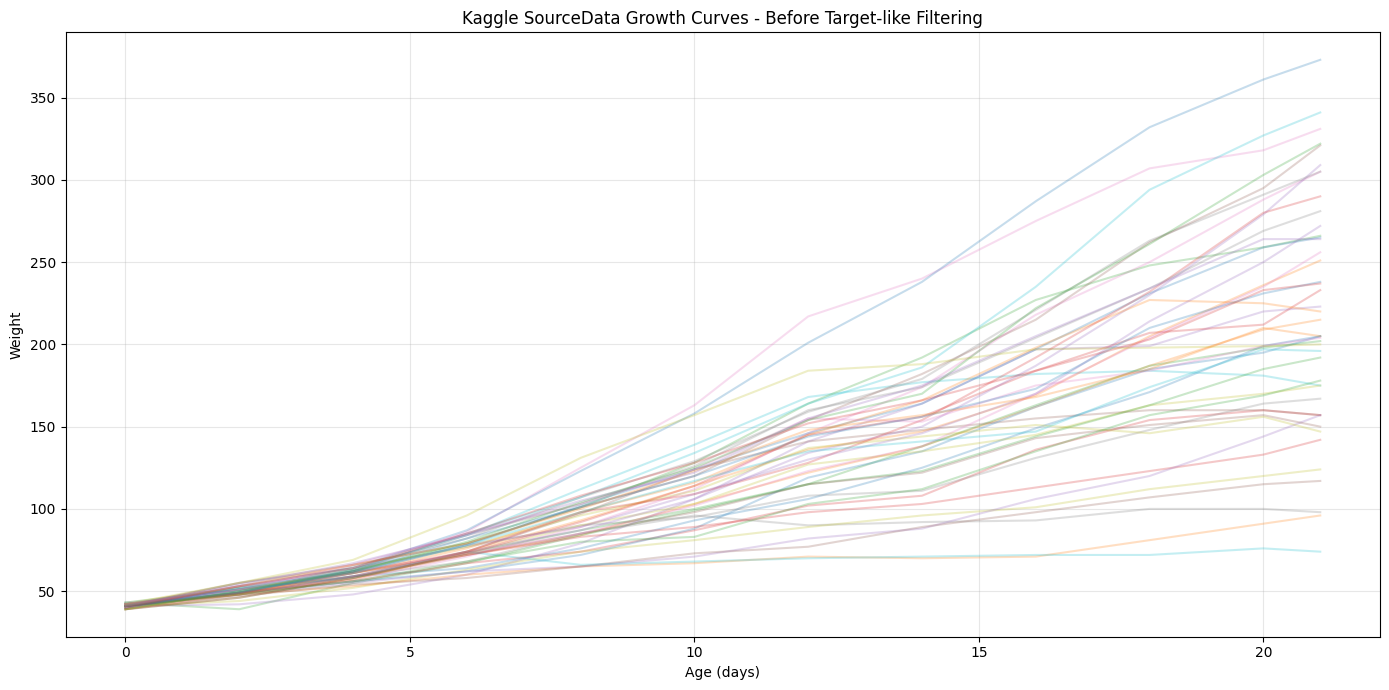

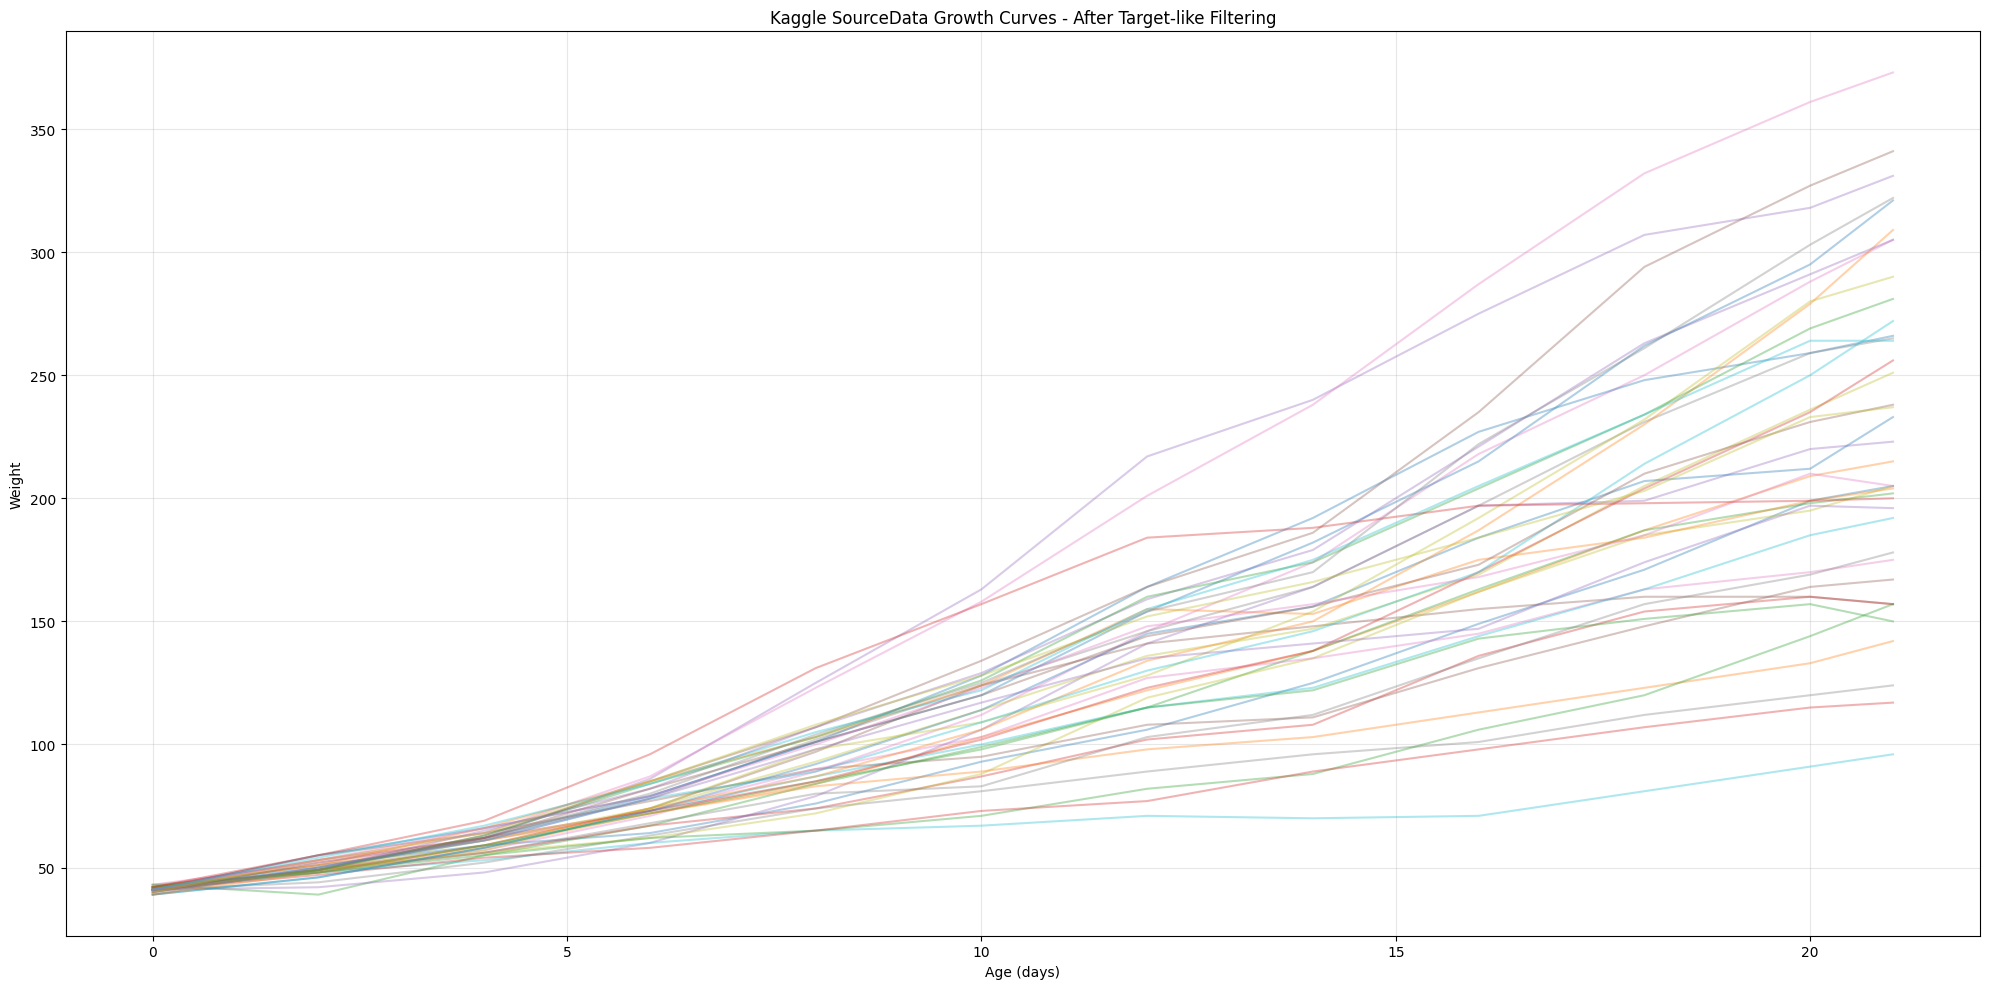

In [24]:
# 視覺化所有雞隻生長曲線
# === Step 6-1. 視覺化：篩選前所有 Kaggle 生長曲線 ===
plt.figure(figsize=(14, 7))
for chick, group in data.groupby("Chick"):
    group = group.sort_values("Age")
    plt.plot(group["Age"], group["weight"], alpha=0.25)
plt.xlabel("Age (days)")
plt.ylabel("Weight")
plt.title("Kaggle SourceData Growth Curves - Before Target-like Filtering")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# === Step 6-2. 視覺化：篩選後 Target-like Kaggle 生長曲線 ===
plt.figure(figsize=(20, 10))
for chick, group in data_source_target_like.groupby("Chick"):
    group = group.sort_values("Age")
    plt.plot(group["Age"], group["weight"], alpha=0.35)
plt.xlabel("Age (days)")
plt.ylabel("Weight")
plt.title("Kaggle SourceData Growth Curves - After Target-like Filtering")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# === Step 8. 匯出 Kaggle SourceData 前處理結果 ===

kaggle_growth_pivot.to_csv(
    "Kaggle_growth_pivot_all.csv",
    encoding="utf-8-sig"
)

kaggle_growth_check.to_csv(
    "Kaggle_growth_curve_check.csv",
    index=False,
    encoding="utf-8-sig"
)

kaggle_growth_pivot_target_like.to_csv(
    "Kaggle_growth_pivot_target_like.csv",
    encoding="utf-8-sig"
)

data_source_target_like.to_csv(
    "Kaggle_SourceData_target_like_daily.csv",
    index=False,
    encoding="utf-8-sig"
)

# kaggle_daily_stats.to_csv(
#     "Kaggle_SourceData_target_like_daily_stats.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

print("已輸出：")
print("1. Kaggle_growth_pivot_all.csv")
print("2. Kaggle_growth_curve_check.csv")
print("3. Kaggle_growth_pivot_target_like.csv")
print("4. Kaggle_SourceData_target_like_daily.csv")
# print("5. Kaggle_SourceData_target_like_daily_stats.csv")

已輸出：
1. Kaggle_growth_pivot_all.csv
2. Kaggle_growth_curve_check.csv
3. Kaggle_growth_pivot_target_like.csv
4. Kaggle_SourceData_target_like_daily.csv


<h3> 視覺化圖表 </h3>

In [26]:
# === Step 1. 讀取 Target-like Kaggle SourceData ===
file_path = "Kaggle_SourceData_target_like_daily.csv"
data = pd.read_csv(file_path)

# 基本檢查
data = data.sort_values(["Chick", "Age"]).reset_index(drop=True)
print("資料形狀:", data.shape)
print("欄位:", data.columns.tolist())
print("雞隻數:", data["Chick"].nunique())
print("Age 範圍:", data["Age"].min(), "~", data["Age"].max())
print("缺失值:")
print(data.isnull().sum())
print("\n每隻雞資料筆數分布:")
print(data.groupby("Chick")["Age"].count().value_counts().sort_index())

data

資料形狀: (880, 3)
欄位: ['Chick', 'Age', 'weight']
雞隻數: 40
Age 範圍: 0 ~ 21
缺失值:
Chick     0
Age       0
weight    0
dtype: int64

每隻雞資料筆數分布:
Age
22    40
Name: count, dtype: int64


,Chick,Age,weight
0,1,0,42.0
1,1,1,46.5
2,1,2,51.0
3,1,3,55.0
4,1,4,59.0
...,...,...,...
875,50,17,219.5
876,50,18,234.0
877,50,19,249.0
878,50,20,264.0


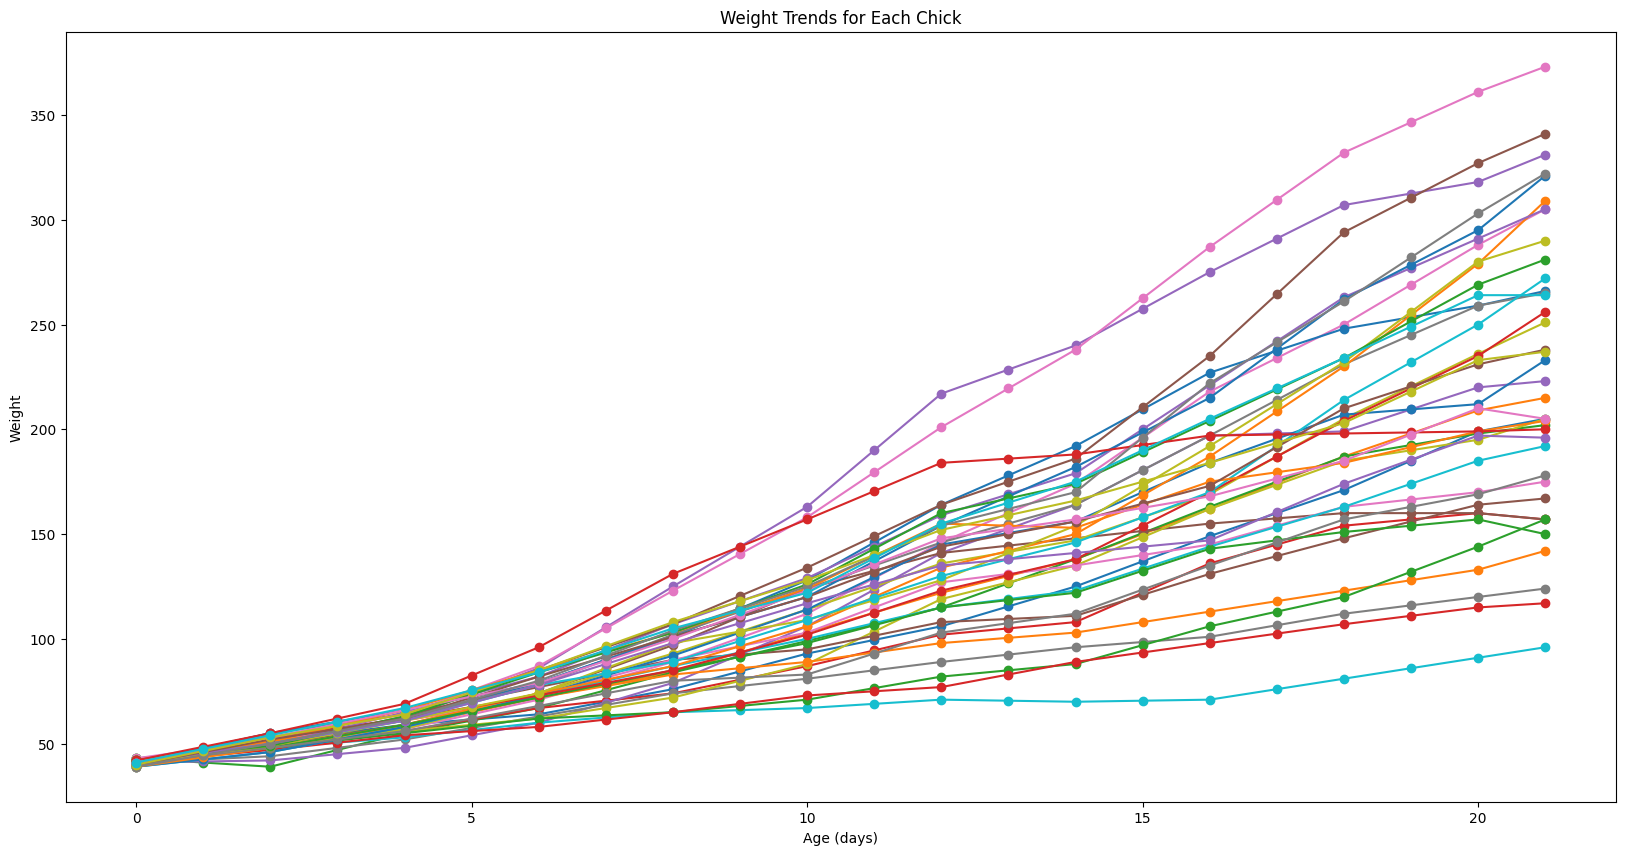

In [27]:
# 只保留有完整21天日齡的雞隻曲線
plot_chick_growth(data) # 繪製所有雞隻生長曲線

回歸線方程式: y = 9.31x + 25.10


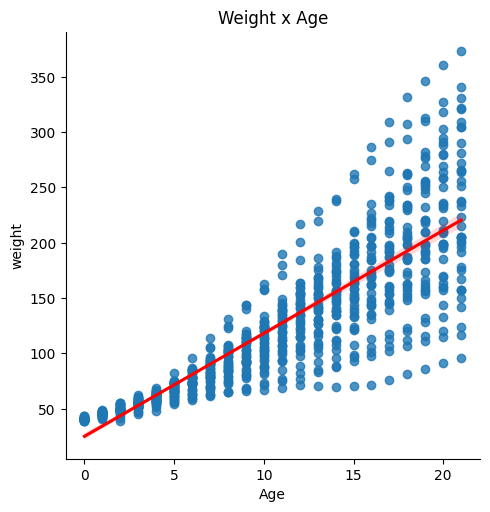

In [28]:
# 若用 回歸線方程式 觀察曲線
sns.lmplot(data=data, x='Age', y='weight', line_kws={'color': 'red'})
plt.title('Weight x Age')

# 将数据转换为适合 sklearn 的格式
Age = np.array(data['Age']).reshape(-1, 1)  # 特征变量，需要是二维数组
weight = np.array(data['weight'])  # 目标变量
# 创建线性回归模型实例
model = LinearRegression()
# 拟合模型
model.fit(Age, weight)
# 获取斜率（slope）和截距（intercept）
slope = model.coef_[0]
intercept = model.intercept_
print(f"回歸線方程式: y = {slope:.2f}x + {intercept:.2f}")

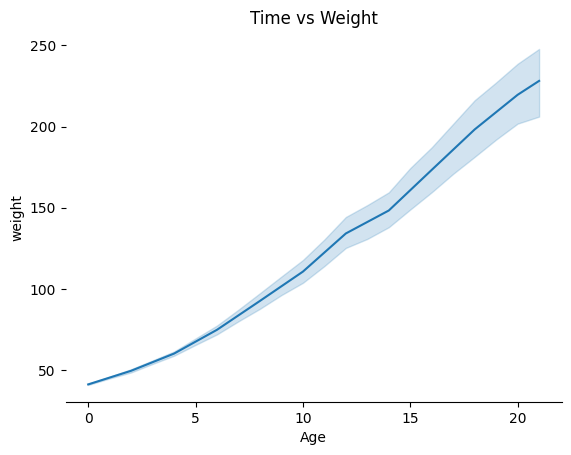

In [29]:
# 繪製lineplot
sns.lineplot(data=data, x="Age", y="weight")
sns.despine(left=True) # 設定边框线，使图表更加简洁美观。
plt.title("Time vs Weight")
plt.show()

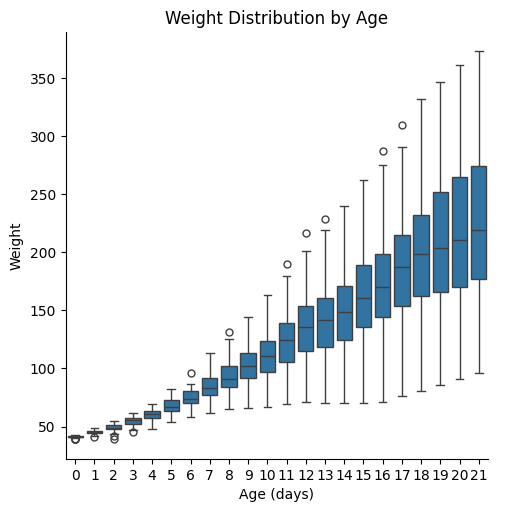

In [30]:
# catplot
sns.catplot(data=data, x="Age", y="weight", kind='box')
plt.title("Weight Distribution by Age")
plt.xlabel("Age (days)")
plt.ylabel("Weight")
plt.show()

<h3> 每日聚合 → 統計特徵 </h3>

In [31]:
# === Step 2. 依照 Age 建立 daily statistics ===
# 按照日齡把資料分組，只對 weight 欄位做計算，對每組（同一天所有雞的體重）呼叫你定義的 daily_features，算出最小值、最大值、IQR、中位數、平均數等統計特徵，最後再把 Age 從 groupby 索引還原成一般欄位，方便後續分析。
kaggle_source_daily_stats = (
    data
    .groupby("Age")["weight"]
    .apply(daily_features)
    .reset_index()
)

# 整理欄位名稱，避免 level_1 / weight 名稱不穩
kaggle_source_daily_stats = kaggle_source_daily_stats.rename(
    columns={
        "level_1": "feature",
        "weight": "value"
    }
)

# 轉成寬表
kaggle_source_daily_stats = (
    kaggle_source_daily_stats
    .pivot(index="Age", columns="feature", values="value")
    .reset_index()
)

kaggle_source_daily_stats.columns.name = None

# 調整欄位順序，對齊福壽 daily_stats
kaggle_source_daily_stats = kaggle_source_daily_stats[
    ["Age", "min", "max", "range", "p25", "p75", "IQR", "median", "std", "mean"]
]

kaggle_source_daily_stats

,Age,min,max,range,p25,p75,IQR,median,std,mean
0,0,39.0,43.0,4.0,41.000,42.000,1.000,41.00,1.047280,41.0750
1,1,41.0,48.5,7.5,44.500,46.500,2.000,45.00,1.735563,45.2750
2,2,39.0,55.0,16.0,48.000,51.250,3.250,49.00,3.297143,49.4750
3,3,45.0,62.0,17.0,52.500,57.000,4.500,55.50,3.688079,54.7750
4,4,48.0,69.0,21.0,57.000,63.000,6.000,61.00,4.480084,60.0750
5,5,54.0,82.5,28.5,63.500,72.500,9.000,67.25,6.421007,67.4125
6,6,58.0,96.0,38.0,70.250,80.500,10.250,74.00,8.696448,74.7500
7,7,61.5,113.5,52.0,77.000,91.625,14.625,83.50,12.010786,83.6500
8,8,65.0,131.0,66.0,83.750,102.250,18.500,91.00,15.617134,92.5500
9,9,66.0,144.0,78.0,91.500,113.500,22.000,101.75,18.820185,101.5750


In [32]:
kaggle_source_daily_stats.shape

(22, 10)

<h3> Scaler 標準化 </h3>

In [33]:
# 存檔
kaggle_source_daily_stats.to_csv("kaggle_chicks_daily_features.csv", index=True)
print("已輸出 kaggle_chicks_daily_features.csv")

已輸出 kaggle_chicks_daily_features.csv


In [34]:
# 複製一份避免覆蓋原始
df_scaled = kaggle_source_daily_stats.copy()
df_scaled = df_scaled.sort_values("Age").reset_index(drop=True)

In [35]:
df_scaled

,Age,min,max,range,p25,p75,IQR,median,std,mean
0,0,39.0,43.0,4.0,41.000,42.000,1.000,41.00,1.047280,41.0750
1,1,41.0,48.5,7.5,44.500,46.500,2.000,45.00,1.735563,45.2750
2,2,39.0,55.0,16.0,48.000,51.250,3.250,49.00,3.297143,49.4750
3,3,45.0,62.0,17.0,52.500,57.000,4.500,55.50,3.688079,54.7750
4,4,48.0,69.0,21.0,57.000,63.000,6.000,61.00,4.480084,60.0750
5,5,54.0,82.5,28.5,63.500,72.500,9.000,67.25,6.421007,67.4125
6,6,58.0,96.0,38.0,70.250,80.500,10.250,74.00,8.696448,74.7500
7,7,61.5,113.5,52.0,77.000,91.625,14.625,83.50,12.010786,83.6500
8,8,65.0,131.0,66.0,83.750,102.250,18.500,91.00,15.617134,92.5500
9,9,66.0,144.0,78.0,91.500,113.500,22.000,101.75,18.820185,101.5750


<h4> 建立 scaler 並 fit_transform 特徵欄位 </h4>
<p> ConsistentWithPrevious </p>

<p style="color:blue"> 本階段前處理暫採與前期 LSTM/xLSTM 實驗一致之 MinMaxScaler 流程，即先對整體資料進行尺度縮放後再依時間順序切分 train/test；後續正式實驗將補充 train-only scaler 版本作為敏感度檢查，以確認 scaling 流程對模型結果之影響。 </p>

<p style="color:green"> (口試答辯時)前期實驗為了維持不同資料集之間的前處理一致性，皆採用 MinMaxScaler 將數值壓縮至 0～1 區間後再進行模型訓練。後續在整理正式論文時，我也注意到若 scaler 先 fit 全資料，測試集的範圍資訊會參與前處理。因此我會將這些結果定位為前期一致性實驗，並補充 train-only scaler 版本作為正式流程或敏感度檢查，以確認主要趨勢是否穩定。</p>

In [36]:
# === Step 1. 指定目標與特徵欄位  ===
feature_cols = ["min","max","range","p25","p75","IQR","median","std"]
target_col = "mean"

In [37]:
# === Step 2. 先把 DataFrame 裡的數據直接標準化 (Scaling) ===
# 注意：此版本為「FullDataScaler」版本，目的是與前期實驗流程保持一致。
feature_scaler  = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。
target_scaler  = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。

# 特徵 scaling
df_scaled[feature_cols] = feature_scaler.fit_transform(df_scaled[feature_cols])
# 目標 scaling
df_scaled[target_col] = target_scaler.fit_transform(df_scaled[[target_col]])

<h4> Save Dataset & 拆分資料 </h4>

In [38]:
# 存檔，存成 CSV，方便之後重複使用或 Debug。
df_scaled.to_csv("kaggle_chicks_daily_features(Normalized).csv", index=True)
print("已輸出 kaggle_chicks_daily_features(Normalized)")

已輸出 kaggle_chicks_daily_features(Normalized)


In [39]:
# === Step 3.再拆成 X（特徵） 和 y（目標）===
X = df_scaled[feature_cols].values
y = df_scaled[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22, 8)
y shape: (22,)


In [40]:
# === Step 4. Train/Test Split (前 70% 為 train，後 30% 為 test) ===
split_index = int(len(df_scaled) * 0.7)

X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)

print("Train Age range:", df_scaled.iloc[:split_index]["Age"].min(), "~", df_scaled.iloc[:split_index]["Age"].max())
print("Test Age range:", df_scaled.iloc[split_index:]["Age"].min(), "~", df_scaled.iloc[split_index:]["Age"].max())


Train shape: (15, 8) (15,)
Test  shape: (7, 8) (7,)
Train Age range: 0 ~ 14
Test Age range: 15 ~ 21


In [41]:
# === Step 5. 儲存成 pkl 檔案 ===
data_dic = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
    "feature_scaler": feature_scaler,  # 存下來方便 inverse_transform
    "target_scaler": target_scaler
}

In [42]:
folder_name = "70%Training_30%Testing"
os.makedirs(folder_name, exist_ok=True)

for key, value in data_dic.items():
    file_path = os.path.join(folder_name, f"{key}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(value, f)
    print(f"已儲存：{file_path}")

已儲存：70%Training_30%Testing\X_train.pkl
已儲存：70%Training_30%Testing\y_train.pkl
已儲存：70%Training_30%Testing\X_test.pkl
已儲存：70%Training_30%Testing\y_test.pkl
已儲存：70%Training_30%Testing\feature_scaler.pkl
已儲存：70%Training_30%Testing\target_scaler.pkl
